In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Phenotypes

In [9]:
dpheno1 = pd.read_csv("../43_climate_transfer_distance/10_correct_Etienne_phenotypes_corrected.tsv", sep="\t", header=0)
dpheno1 = dpheno1[['genotype', 'POP_ID', 'Trait', 'SITE_ID', 'value_corrected']].reset_index(drop=True)
dpheno1.head()
dpheno1[dpheno1.isnull().any(axis=1)]
print(dpheno1['genotype'].drop_duplicates().shape)
dpheno1.head()

(1997,)


,genotype,POP_ID,Trait,SITE_ID,value_corrected
0,E353-B3_3_10_6986_369,6986,Average_Ring_Density,CH,443.300000
1,E353-B3_3_11_6986_370,6986,Average_Ring_Density,CH,436.132143
2,E353-B3_3_14_6986_371,6986,Average_Ring_Density,CH,498.200000
3,E353-B3_3_15_6986_372,6986,Average_Ring_Density,CH,508.614815
4,E353-B3_3_15_6804_408,6804,Average_Ring_Density,CH,577.300000


In [8]:
dpheno2 = pd.read_csv("../43_climate_transfer_distance/08_correct_Patrick_phenotypes_corrected.tsv", sep="\t", header=0)
print(dpheno2['genotype'].drop_duplicates().shape)
#dpheno2.head()

(2010,)


In [5]:
#[ele for ele in dpheno2['Sample_ID'].values if ele == "E353-B1_3_2_3268_169"]

In [6]:
dstack = dpheno2[['genotype', 'POP_ID', 'SITE_ID', 'Height_corrected', 'DBH_corrected']].set_index(['genotype', 'POP_ID', 'SITE_ID']).stack().reset_index().rename(columns={0:'value_corrected'})
dstack['Trait'] = dstack['level_3'].apply(lambda x: x.split('_')[0])
dstack = dstack.drop(columns = "level_3")[['genotype', 'POP_ID', 'Trait', 'SITE_ID', 'value_corrected']].reset_index(drop=True)
dstack.head()

,genotype,POP_ID,Trait,SITE_ID,value_corrected
0,E353-B3_2_6_325_670,325,Height,CH,1017.799735
1,E353-B3_2_6_325_670,325,DBH,CH,98.056964
2,E353-B3_2_6_4360_580,4360,Height,CH,803.713025
3,E353-B3_2_6_4360_580,4360,DBH,CH,109.777801
4,E353-B3_2_9_6804_556,6804,Height,CH,315.477770


In [8]:
dstack[dstack.isnull().any(axis=1)]
print(dstack['genotype'].drop_duplicates().shape)

(2010,)


In [13]:
# Extreme values
dpheno3 = pd.read_csv("../43_climate_transfer_distance/12_correct_Extreme_phenotypes_corrected.tsv", sep="\t", header=0)
print(dpheno3['genotype'].drop_duplicates().shape)
dpheno3 = dpheno3[['genotype','POP_ID','Trait','SITE_ID','value_corrected']].reset_index(drop=True)
dpheno3.head()

(1929,)


,genotype,POP_ID,Trait,SITE_ID,value_corrected
0,E353-B3_3_10_1329_335,1329,Rc,CH,1.1330
1,E353-B3_3_10_1531_491,1531,Rc,CH,0.9480
2,E353-B3_3_10_1534_296,1534,Rc,CH,1.0540
3,E353-B3_3_10_1538_411,1538,Rc,CH,1.0360
4,E353-B3_3_10_325_321,325,Rc,CH,1.0495


In [16]:
dpheno = pd.concat([dpheno1, dstack, dpheno3], ignore_index=True)
dpheno['POP_ID'] = dpheno['POP_ID'].astype('str')
print(dpheno.shape)
print(dpheno['genotype'].drop_duplicates().shape)
dpheno.head()

(31128, 5)
(2181,)


,genotype,POP_ID,Trait,SITE_ID,value_corrected
0,E353-B3_3_10_6986_369,6986,Average_Ring_Density,CH,443.300000
1,E353-B3_3_11_6986_370,6986,Average_Ring_Density,CH,436.132143
2,E353-B3_3_14_6986_371,6986,Average_Ring_Density,CH,498.200000
3,E353-B3_3_15_6986_372,6986,Average_Ring_Density,CH,508.614815
4,E353-B3_3_15_6804_408,6804,Average_Ring_Density,CH,577.300000


In [18]:
dpiv = pd.pivot_table(dpheno, index = ['genotype','POP_ID', 'SITE_ID'], columns = 'Trait', values = 'value_corrected').reset_index()
dpiv.tail()

Trait,genotype,POP_ID,SITE_ID,Average_Ring_Density,Biomass_Increment,Biomass_Increment_1980,Biomass_Increment_1985,Biomass_Increment_1990,Biomass_Increment_1995,Biomass_Increment_2000,Biomass_Increment_2005,Biomass_Increment_2010,Biomass_Increment_2015,DBH,Height,Rc,Rl,Rr,Rs
2176,E60A-6_7_12_601,6971,AC,462.070990,3.859594,-0.252611,2.011320,2.430588,2.383115,2.147690,1.904338,0.648343,-1.432604,141.149717,1252.331446,1.014176,0.692630,0.002707,0.680801
2177,E60A-6_7_2_775,4420,AC,476.947423,3.670993,NaN,1.008216,2.191570,1.958183,1.787782,1.964846,2.116978,0.419782,NaN,NaN,0.904570,0.658284,-0.020964,0.682095
2178,E60A-6_7_4_778,7003,AC,601.735202,3.689168,NaN,0.683818,1.759089,2.136221,2.064292,1.914179,2.197618,0.695189,148.441464,1498.485875,1.044159,0.762077,0.041612,0.719065
2179,E60A-6_8_2_185,4420,AC,439.947423,4.382677,-0.144092,2.193349,2.607747,2.619009,2.564726,2.484191,3.004227,1.127979,187.623936,1476.487831,0.987904,0.760284,-0.009964,0.773428
2180,E60A-6_8_32_274,6937,AC,399.437855,3.404069,-1.029606,1.727517,2.296268,1.866503,1.530227,0.857174,0.176269,-1.970998,114.460944,1059.581829,0.848848,0.587710,-0.102108,0.685553


In [19]:
print(dpiv['genotype'].drop_duplicates().shape)

(2181,)


In [20]:
dpiv['genotype'].shape
dpiv.columns

Index(['genotype', 'POP_ID', 'SITE_ID', 'Average_Ring_Density',
       'Biomass_Increment', 'Biomass_Increment_1980', 'Biomass_Increment_1985',
       'Biomass_Increment_1990', 'Biomass_Increment_1995',
       'Biomass_Increment_2000', 'Biomass_Increment_2005',
       'Biomass_Increment_2010', 'Biomass_Increment_2015', 'DBH', 'Height',
       'Rc', 'Rl', 'Rr', 'Rs'],
      dtype='object', name='Trait')

In [21]:
dstats = dpiv.groupby(['POP_ID','SITE_ID']).agg(n = ('genotype','count'), n_height = ('Height','count'), n_biomass = ('Biomass_Increment','count')).reset_index().sort_values(by=["SITE_ID","POP_ID"])
dstats.head()

,POP_ID,SITE_ID,n,n_height,n_biomass
0,1329,AC,15,14,13
4,1530,AC,15,13,14
7,1531,AC,15,12,15
10,1534,AC,15,13,11
13,1538,AC,15,12,15


In [15]:
print(dstats['POP_ID'].drop_duplicates().shape)

(67,)


# Genotypes - samples selected for GEA (no WI or MA)

In [22]:
dmeta = pd.read_csv("../35_GEA_input_prep/01_filter_snps_indiv_metrics.tsv", sep="\t", header=0)
print(dmeta.shape)
dmeta = dmeta[['id', 'POP', 'SITE_ID','STRATA', 'region', 'cluster', 'group']]
dmeta["POP"] = dmeta["POP"].apply(lambda x: str(x))
dmeta["POP_SITE"] = dmeta.apply(lambda x: str(x["POP"]) + "_" + x["SITE_ID"], axis=1)
dmeta.head()

(1433, 7)


,id,POP,SITE_ID,STRATA,region,cluster,group,POP_SITE
1,E353-B1_3_6_333_001,333,ML,G,G,Central,Central,333_ML
2,E353-B1_3_6_6914_073,6914,ML,F,F,Central,Central,6914_ML
3,E353-B1_3_16_6917_081,6917,ML,E,E,Central,Central,6917_ML
4,E353-B3_3_7_6802_478,6802,CH,I,I,East,East,6802_CH
5,E353-B3_3_14_6986_371,6986,CH,C,C,West,West,6986_CH


In [23]:
dstats2 = dmeta.groupby(["POP","SITE_ID"]).agg(n_genos = ('id','count')).reset_index().sort_values(by=["SITE_ID","POP"]).rename(columns = {"POP":"POP_ID"})
dstats3 = pd.merge(dstats, dstats2, on = ["POP_ID","SITE_ID"], how = "left")
dstats3["n_genos"] = dstats3["n_genos"].fillna(0).astype(int)

dstats3.head()

,POP_ID,SITE_ID,n,n_height,n_biomass,n_genos
0,1329,AC,15,14,13,2
1,1530,AC,15,13,14,0
2,1531,AC,15,12,15,0
3,1534,AC,15,13,11,2
4,1538,AC,15,12,15,0


In [24]:
print(dstats3['POP_ID'].drop_duplicates().shape)

(67,)


In [25]:
dstats3.to_excel("00_combine_samples_check.xlsx")

# TRAIN AND TEST

### Table prep

In [26]:
dmeta_geno = dmeta[['id']].reset_index(drop=True)
print(dmeta_geno.shape)
#dmeta_geno[]
dmeta_calls = pd.read_csv("../03_admixture_EPR_EPN/admixture_04_combine_output_assigned_clusters.tsv", sep="\t", header=0)
dmeta_calls = dmeta_calls[['id','call_rate']].reset_index(drop=True)
#dmeta_calls.to_excel("check.xlsx")
print(dmeta_calls.shape)
dmeta_comb = pd.merge(dmeta_geno, dmeta_calls, on = 'id', how = 'left')
dmeta_comb = dmeta_comb.rename(columns={'id':'genotype'}).reset_index(drop=True)
print(dmeta_comb.shape)

# Merge with phenotypes
mpiv = pd.merge(dpiv, dmeta_comb, on = 'genotype', how = 'left')
mpiv['good_genotype'] = mpiv['call_rate'].apply(lambda x: True if x>0 else False)
print(mpiv.shape)
mpiv.head()
mpiv[['genotype', 'POP_ID', 'SITE_ID', 'call_rate', 'good_genotype','Height']].sort_values(by=['SITE_ID','POP_ID','good_genotype','call_rate'],
                                                                                           ascending=[False,True,True,False]).head(20)

(1433, 1)
(2268, 2)
(1433, 2)
(2181, 21)


,genotype,POP_ID,SITE_ID,call_rate,good_genotype,Height
28,443-G348-1-17-4,2209,PR,NaN,False,975.525258
272,741-G348-2-17-1,2209,PR,NaN,False,1175.525258
273,742-G348-2-17-2,2209,PR,NaN,False,1215.525258
297,773-G348-3-17-4,2209,PR,NaN,False,555.525258
299,775-G348-3-17-7,2209,PR,0.934013,True,545.525258
300,776-G348-3-17-8,2209,PR,0.927366,True,1035.525258
296,772-G348-3-17-2,2209,PR,0.900876,True,1155.525258
27,441-G348-1-17-1,2209,PR,0.891129,True,1135.525258
295,771-G348-3-17-1,2209,PR,0.874832,True,1165.525258
30,446-G348-1-17-8,2209,PR,0.874257,True,525.525258


# Loop

In [38]:
test_thresh = 3 # minimum for test below which loop is triggered
train_thresh = 5 # minimum for train below which loop is stopped

In [39]:
pop_sites = mpiv[["POP_ID","SITE_ID"]].drop_duplicates().values.tolist()

In [40]:
def sample_test_train(dataset, trait):
    R = []
    for pop_site in pop_sites:
    
        #print(pop_site)
        # samples from a selected pop-site
        mpiv_sub = dataset.loc[(dataset['POP_ID']==pop_site[0])&(dataset['SITE_ID']==pop_site[1]),['genotype','POP_ID','SITE_ID',trait,'call_rate','good_genotype']].reset_index(drop=True)
        # samples with good genotype and phenotype
        mpiv_geno_pheno = mpiv_sub[(mpiv_sub['good_genotype']==True)&(mpiv_sub[trait]>0)].sort_values(by='call_rate').reset_index(drop=True)
        # samples with good genotype but no phenotype
        mpiv_geno = mpiv_sub[(mpiv_sub['good_genotype']==True)&(mpiv_sub[trait].isna())].sort_values(by='call_rate').reset_index(drop=True)
        # samples with phenotype but no good genotype
        mpiv_pheno = mpiv_sub[mpiv_sub['good_genotype']==False].dropna(subset=trait).reset_index(drop=True)
        
        # lists with ids
        id_geno = mpiv_geno['genotype'].values.tolist()
        id_geno_pheno = mpiv_geno_pheno['genotype'].values.tolist()
        id_pheno = mpiv_pheno['genotype'].values.tolist()
        
        #print(len(id_geno)+len(id_geno_pheno), len(id_pheno))
        
        # only if there is less phenotypes in test than required
        while len(id_pheno) < test_thresh:
            #print(len(id_pheno))
            # only if there is +1 genotypes to choose from
            if (len(id_geno)+len(id_geno_pheno) > train_thresh) & (len(id_geno_pheno)>0):
                #print(len(id_geno)+len(id_geno_pheno))
                # add first element of genotypes (train) to phenotypes (test)
                id_pheno+=[id_geno_pheno[0]]
                # remove first element of genotypes (train)
                id_geno_pheno = id_geno_pheno[1:]
            else:
                break
        
        train_set = id_geno + id_geno_pheno
        test_set = id_pheno
        
        P = []
        for ele in train_set:
            r = [trait, ele, pop_site[0], pop_site[1], "TRAIN"]
            P.append(r)
        for ele in test_set:
            s = [trait, ele, pop_site[0], pop_site[1], "TEST"]
            P.append(s)
            
        dP = pd.DataFrame(P)
        R.append(dP)
        
    dR = pd.concat(R, ignore_index=True)
    dR.columns = ['Trait_name', 'genotype','POP_ID','SITE_ID','SET']

    mpiv_trait = mpiv[['genotype', 'POP_ID', 'SITE_ID', 'call_rate', 'good_genotype',trait]].reset_index(drop=True)
    mpiv_trait = mpiv_trait.rename(columns = {trait : "value"}).reset_index(drop=True)
    mpiv_merged = pd.merge(mpiv_trait, dR, on = ['genotype','POP_ID', 'SITE_ID'], how='left')
    mpiv_merged = mpiv_merged.sort_values(by=['SITE_ID','POP_ID','good_genotype']).reset_index(drop=True)

    # Removing samples from pop-sizes with less than 5 samples in train dataset
    mpiv_merged["POP_SITE"] = mpiv_merged.apply(lambda x: x["POP_ID"] + "_" + x["SITE_ID"], axis=1)
    stats = mpiv_merged[mpiv_merged["SET"] == "TRAIN"].groupby(["POP_SITE"])[["genotype"]].count()
    stats[stats["genotype"] < 5]
    pop_sites_list = stats[stats["genotype"] < 5].index.values
    fpiv_merged = mpiv_merged[~mpiv_merged["POP_SITE"].isin(pop_sites_list)].reset_index(drop=True)

    return(fpiv_merged)

# Test and train for all traits

In [41]:
traits = ['Average_Ring_Density',
       'Biomass_Increment', 'Biomass_Increment_1980', 'Biomass_Increment_1985',
       'Biomass_Increment_1990', 'Biomass_Increment_1995',
       'Biomass_Increment_2000', 'Biomass_Increment_2005',
       'Biomass_Increment_2010', 'Biomass_Increment_2015', 'DBH', 'Height',
        'Rc', 'Rl', 'Rr', 'Rs']
mpiv.columns

Index(['genotype', 'POP_ID', 'SITE_ID', 'Average_Ring_Density',
       'Biomass_Increment', 'Biomass_Increment_1980', 'Biomass_Increment_1985',
       'Biomass_Increment_1990', 'Biomass_Increment_1995',
       'Biomass_Increment_2000', 'Biomass_Increment_2005',
       'Biomass_Increment_2010', 'Biomass_Increment_2015', 'DBH', 'Height',
       'Rc', 'Rl', 'Rr', 'Rs', 'call_rate', 'good_genotype'],
      dtype='object')

In [42]:
T = []
for my_trait in traits:
    dt = sample_test_train(mpiv, my_trait)
    T.append(dt)

In [43]:
dt

,genotype,POP_ID,SITE_ID,call_rate,good_genotype,value,Trait_name,SET,POP_SITE
0,E60A-3_1_84_089,1530,AC,NaN,False,0.752751,Rs,TEST,1530_AC
1,E60A-3_3_84_091,1530,AC,NaN,False,0.656418,Rs,TEST,1530_AC
2,E60A-3_5_84_090,1530,AC,NaN,False,0.753751,Rs,TEST,1530_AC
3,E60A-3_6_84_093,1530,AC,NaN,False,0.795084,Rs,TEST,1530_AC
4,E60A-3_7_84_094,1530,AC,NaN,False,0.866751,Rs,TEST,1530_AC
...,...,...,...,...,...,...,...,...,...
2086,632-G348-2-15-7,6999,PR,0.912763,True,0.797538,Rs,TRAIN,6999_PR
2087,633-G348-2-15-9,6999,PR,0.900268,True,0.877538,Rs,TRAIN,6999_PR
2088,915-G348-3-15-1,6999,PR,0.879530,True,0.916038,Rs,TRAIN,6999_PR
2089,916-G348-3-15-3,6999,PR,0.867483,True,0.868038,Rs,TRAIN,6999_PR


In [44]:
dT = pd.concat(T, ignore_index=True)
dT.head()

,genotype,POP_ID,SITE_ID,call_rate,good_genotype,value,Trait_name,SET,POP_SITE
0,E60A-3_1_84_089,1530,AC,NaN,False,513.677825,Average_Ring_Density,TEST,1530_AC
1,E60A-3_3_84_091,1530,AC,NaN,False,554.737825,Average_Ring_Density,TEST,1530_AC
2,E60A-3_5_84_090,1530,AC,NaN,False,580.927825,Average_Ring_Density,TEST,1530_AC
3,E60A-3_6_84_093,1530,AC,NaN,False,575.127825,Average_Ring_Density,TEST,1530_AC
4,E60A-3_7_84_094,1530,AC,NaN,False,567.897825,Average_Ring_Density,TEST,1530_AC


In [45]:
dT.to_csv("00_combine_samples.tsv", sep="\t", header=True, index=False)

# Table

In [86]:
dT_sub = dT[(dT['SET'].isin(['TEST','TRAIN']))].reset_index(drop=True)
dT_sub.head()
print(dT.shape, dT_sub.shape)
dg = dT_sub.groupby(['SITE_ID','Trait_name','SET']).agg(n_pop = ('POP_ID','nunique'), n_gen = ('genotype','nunique'))
#dg_stack = dg.stack().reset_index().rename(columns = {'level_3':'level',0:'value'})
#dg_stack.head()
dg_pop = dg['n_pop'].reset_index()
dg_gen = dg['n_gen'].reset_index()
dg_pop.head()

(32093, 9) (29715, 9)


,SITE_ID,Trait_name,SET,n_pop
0,AC,Average_Ring_Density,TEST,32
1,AC,Average_Ring_Density,TRAIN,10
2,AC,Biomass_Increment,TEST,32
3,AC,Biomass_Increment,TRAIN,10
4,AC,Biomass_Increment_1980,TEST,27


In [82]:
piv_pop = pd.pivot_table(dg_pop, index = 'Trait_name', columns = ['SITE_ID','SET'], values = 'n_pop')
piv_pop = piv_pop.astype(int)
piv_pop.to_excel("00_combine_samples_table_pop.xlsx")

In [84]:
piv_gen = pd.pivot_table(dg_gen, index = 'Trait_name', columns = ['SITE_ID','SET'], values = 'n_gen')
piv_gen = piv_gen.astype(int)
piv_gen.to_excel("00_combine_samples_table_gen.xlsx")
piv_gen

SITE_ID                  AC         CH         ML         PR      
SET                    TEST TRAIN TEST TRAIN TEST TRAIN TEST TRAIN
Trait_name                                                        
Average_Ring_Density    348    84  151   375  149   519  111   288
Biomass_Increment       348    84  151   375  149   519  111   288
Biomass_Increment_1980  276    34   58   159  100   297   32   193
Biomass_Increment_1985  348    84  140   313  148   510   90   207
Biomass_Increment_1990  348    84  151   375  138   514  111   277
Biomass_Increment_1995  348    84  151   375  149   519  111   288
Biomass_Increment_2000  348    84  151   375  149   519  111   288
Biomass_Increment_2005  341    78  151   375  149   519  111   287
Biomass_Increment_2010  332    66  151   368  149   518  111   286
Biomass_Increment_2015  310    28   82   131  129   369   74   166
DBH                     351    84  141   369  156   515  113   289
Height                  351    84  141   369  156   515  113   289
Rc                      342    84  151   375  149   519  100   289
Rl                      342    84  151   375  149   519  101   289
Rr                      333    14   66   107  128   323   90   221
Rs                      342    84  151   375  149   519  101   289

# Trait means per pop-site in test sets

In [46]:
dmeans = dT.groupby(['Trait_name','POP_SITE','POP_ID', 'SITE_ID','SET']).agg(mean = ('value','mean'), sd = ('value','std'),
                                                                            n = ('value','count')).reset_index()
dmeans

,Trait_name,POP_SITE,POP_ID,SITE_ID,SET,mean,sd,n
0,Average_Ring_Density,1329_CH,1329,CH,TEST,476.575417,45.597986,8
1,Average_Ring_Density,1329_CH,1329,CH,TRAIN,465.670982,65.589447,7
2,Average_Ring_Density,1329_ML,1329,ML,TEST,480.010872,108.572664,3
3,Average_Ring_Density,1329_ML,1329,ML,TRAIN,513.398051,52.314507,13
4,Average_Ring_Density,1528_ML,1528,ML,TEST,514.502734,62.179284,3
...,...,...,...,...,...,...,...,...
3781,Rs,6999_PR,6999,PR,TEST,0.680975,0.228647,4
3782,Rs,6999_PR,6999,PR,TRAIN,0.789288,0.079649,11
3783,Rs,7000_CH,7000,CH,TEST,0.936208,0.016256,3
3784,Rs,7000_CH,7000,CH,TRAIN,0.952708,0.085285,10


In [47]:
dmeans.to_csv("00_combine_samples_means.tsv", sep="\t", header=True, index=False)

In [87]:
dmeans[dmeans['n'] == 0]

,Trait_name,POP_SITE,POP_ID,SITE_ID,SET,mean,sd,n
43,Average_Ring_Density,326_ML,326,ML,TRAIN,NaN,NaN,0
67,Average_Ring_Density,338_ML,338,ML,TRAIN,NaN,NaN,0
242,Average_Ring_Density,6988_AC,6988,AC,TRAIN,NaN,NaN,0
293,Biomass_Increment,326_ML,326,ML,TRAIN,NaN,NaN,0
317,Biomass_Increment,338_ML,338,ML,TRAIN,NaN,NaN,0
...,...,...,...,...,...,...,...,...
3606,Rs,338_ML,338,ML,TRAIN,NaN,NaN,0
3769,Rs,6979_PR,6979,PR,TRAIN,NaN,NaN,0
3778,Rs,6986_PR,6986,PR,TRAIN,NaN,NaN,0
3779,Rs,6988_AC,6988,AC,TRAIN,NaN,NaN,0


# Plots

In [48]:
dx = dmeans.set_index(['Trait_name','POP_SITE','POP_ID','SITE_ID','SET']).unstack().reset_index()
dx.columns = ['_'.join(col).strip() for col in dx.columns.values]
dx['count'] = dx['n_TEST'].apply(lambda x: '<3' if x<=3 else '>3')
dx.head()

,Trait_name_,POP_SITE_,POP_ID_,SITE_ID_,mean_TEST,mean_TRAIN,sd_TEST,sd_TRAIN,n_TEST,n_TRAIN,count
0,Average_Ring_Density,1329_CH,1329,CH,476.575417,465.670982,45.597986,65.589447,8.0,7.0,>3
1,Average_Ring_Density,1329_ML,1329,ML,480.010872,513.398051,108.572664,52.314507,3.0,13.0,<3
2,Average_Ring_Density,1528_ML,1528,ML,514.502734,487.240829,62.179284,65.902345,3.0,7.0,<3
3,Average_Ring_Density,1530_AC,1530,AC,553.321396,NaN,48.783433,NaN,14.0,NaN,>3
4,Average_Ring_Density,1530_CH,1530,CH,526.616667,518.358889,93.195567,44.092654,6.0,6.0,>3


In [49]:
#sns.scatterplot(data= dx, x = 'mean_TRAIN', y = 'mean_TEST')

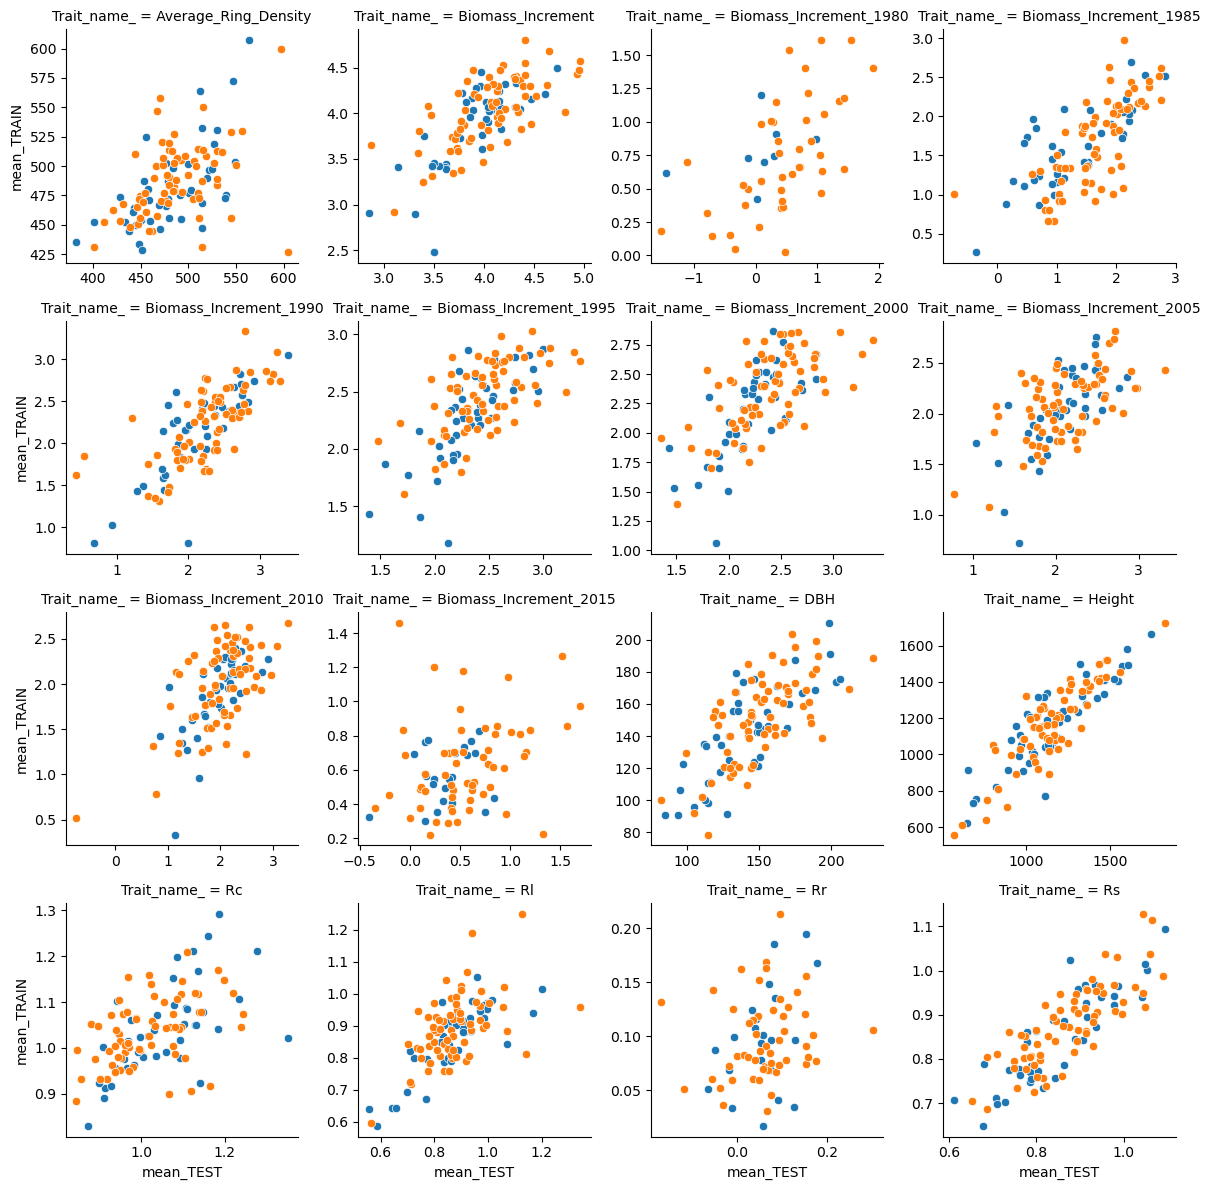

In [50]:
g = sns.FacetGrid(dx, col="Trait_name_", col_wrap=4, sharey=False, sharex=False, hue = 'count')
g.map(sns.scatterplot, "mean_TEST", "mean_TRAIN")
g.figure.savefig("00_combine_samples_mean_TEST_vs_TRAIN.png", dpi=300, bbox_inches='tight')

# END